# 02 — Simulation Walkthrough

**Repository:** `stochastic-physics-simulations`  
**Notebook:** Step-by-step annotated simulation run — from parameter loading to convergence.

---

This notebook walks through a complete simulation run using the engine in `src/mcqhs.py`.
Rather than treating the engine as a black box, each stage is broken down and inspected:

1. Loading and validating input parameters
2. Building the initial configuration
3. Computing the initial system energy
4. Running the MCMC loop with live diagnostics
5. Monitoring acceptance rate and tuning `DISPL`
6. Detecting equilibration and switching to production
7. Writing outputs and preparing for analysis

> **Note:** For speed, this notebook uses a small system (N = 108 particles, 200 000 steps).  
> Production runs typically use N = 256–864 and 10⁶–10⁷ steps.

## Setup

In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')

# import the engine
sys.path.insert(0, os.path.join('..', 'src'))

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'lines.linewidth': 2.0,
})

print("Environment ready.")

Environment ready.


---
## 1. Loading and Validating Input Parameters

All simulation parameters are read from `mc.in`. The function `leer_parametros()` parses
this file and returns a plain tuple — no hidden state, no global variables.

The key derived quantities computed in `inicializar()` are:
- **Box dimensions** in units of σ (from density ρ* and particle count N)
- **Cutoff radius** XMIN — the range of the pair interaction
- **Scaled displacement** DISPL — converted from σ units to box units

In [3]:
# the notebook is self-contained and inspectable.

def leer_parametros(filename='../data/inputs/mc.in'):
    with open(filename, 'r') as f:
        lineas = [l.strip() for l in f if l.strip()]
    N                  = int(lineas[0])
    RHO, XLB           = map(float, lineas[1].split())
    tok                = lineas[2].split()
    NRUN,NMOVE,NSUB    = int(tok[0]), int(tok[1]), int(tok[2])
    DISPL              = float(lineas[3])
    tok                = lineas[4].split()
    NFDR               = int(tok[0])
    LFDR               = tok[1].upper() in ('.TRUE.','TRUE','1','T')
    XHIST              = float(tok[2])
    tok                = lineas[5].split()
    NAC,NCX,NCY,NCZ    = int(tok[0]),int(tok[1]),int(tok[2]),int(tok[3])
    XA = np.zeros(NAC); YA = np.zeros(NAC); ZA = np.zeros(NAC)
    for k in range(NAC):
        t = lineas[6+k].split()
        XA[k],YA[k],ZA[k] = float(t[0]),float(t[1]),float(t[2])
    return (N,RHO,XLB,NRUN,NMOVE,NSUB,DISPL,
            NFDR,LFDR,XHIST,NAC,NCX,NCY,NCZ,XA,YA,ZA)

params = leer_parametros()
(N,RHO,XLB,NRUN,NMOVE,NSUB,DISPL,
 NFDR,LFDR,XHIST,NAC,NCX,NCY,NCZ,XA,YA,ZA) = params

# validation check
assert N == NAC*NCX*NCY*NCZ, f"N={N} must equal NAC*NCX*NCY*NCZ={NAC*NCX*NCY*NCZ}"
assert 0.0 < RHO < 1.2,      f"Density RHO={RHO} out of physical range"
assert 0.0 < DISPL <= 1.0,   f"DISPL={DISPL} should be in (0, 1]"
assert NSUB < NMOVE,          f"NSUB={NSUB} must be less than NMOVE={NMOVE}"

print("=== Simulation Parameters ===")
print(f"  Particles          N     = {N}")
print(f"  Reduced density    ρ*    = {RHO}")
print(f"  de Broglie length  λ_B   = {XLB}")
print(f"  Start mode         NRUN  = {NRUN}  ({'lattice' if NRUN==0 else 'restart'})")
print(f"  Total MC steps     NMOVE = {NMOVE:,}")
print(f"  Block size         NSUB  = {NSUB:,}")
print(f"  Max displacement   DISPL = {DISPL}")
print(f"  Unit cell          NAC×NCX×NCY×NCZ = {NAC}×{NCX}×{NCY}×{NCZ}")
print()
print("All validation checks passed ✓")

=== Simulation Parameters ===
  Particles          N     = 108
  Reduced density    ρ*    = 0.4
  de Broglie length  λ_B   = 0.701301
  Start mode         NRUN  = 0  (lattice)
  Total MC steps     NMOVE = 1,000,000
  Block size         NSUB  = 50,000
  Max displacement   DISPL = 0.25
  Unit cell          NAC×NCX×NCY×NCZ = 4×3×3×3

All validation checks passed ✓


In [4]:
# derived quantities
import math

pi   = math.acos(-1.0)
XLB2 = XLB**2;  XLB3 = XLB**3

# potential minimum (polynomial fit in λ_B)
XMIN  = 1.0194 + 0.14983*XLB - 0.18698*XLB2 + 0.078628*XLB3

# reduced temperature
TEMP  = 0.5 / (XLB2 * pi)

# box geometry (XC=1 by construction)
XN   = float(N)
XNCX = float(NCX); XNCY = float(NCY); XNCZ = float(NCZ)
XC   = 1.0
YC   = XNCY/XNCX;  ZC = XNCZ/XNCX
Y2   = YC/2.0;     Z2 = ZC/2.0

# box side length in units of σ
XL   = (XN / (RHO * YC * ZC))**(1.0/3.0)
YL   = XL * YC;  ZL = XL * ZC

# σ in box units
S    = 1.0/XL;  SS = S*S

# cutoff radius squared (box units)
XMIN2 = XMIN**2 * SS

# potential constants
CTE  = 50.0 * (50.0/49.0)**49
CWK  = XLB2 / (24.0 * pi)
UX0  = CTE * (XMIN**(-50) - XMIN**(-49))
UWK0 = 50*49*XMIN**(-52) - 49*48*XMIN**(-51)
UWT0 = CTE * CWK * UWK0 + UX0

# scale displacement to box units
DISPL_sc = DISPL * S

print("=== Derived System Properties ===")
print(f"  Cutoff radius      r_c   = {XMIN:.5f} σ")
print(f"  Reduced temp       T*    = {TEMP:.4f} kT/ε")
print(f"  Box side (x)       L_x   = {XL:.4f} σ")
print(f"  Box side (y)       L_y   = {YL:.4f} σ")
print(f"  Box side (z)       L_z   = {ZL:.4f} σ")
print(f"  σ in box units     S     = {S:.6f}")
print(f"  Scaled DISPL             = {DISPL_sc:.6f}  (box units)")
print(f"  Potential factor   CTE   = {CTE:.4f}")
print(f"  WK factor          CWK   = {CWK:.6f}")

=== Derived System Properties ===
  Cutoff radius      r_c   = 1.05963 σ
  Reduced temp       T*    = 0.3236 kT/ε
  Box side (x)       L_x   = 6.4633 σ
  Box side (y)       L_y   = 6.4633 σ
  Box side (z)       L_z   = 6.4633 σ
  σ in box units     S     = 0.154720
  Scaled DISPL             = 0.038680  (box units)
  Potential factor   CTE   = 134.5527
  WK factor          CWK   = 0.006523


---
## 2. Building the Initial Configuration

When `NRUN = 0`, particles are placed on a **cubic lattice** by replicating a unit cell
with `NAC` basis sites, `NCX × NCY × NCZ` times.

Starting from a lattice rather than a random configuration avoids overlaps (which would
cause infinite energy). The MCMC loop will progressively disorder the system during
the burn-in phase until it reaches the equilibrium liquid/fluid structure.

In [5]:
# generate cubic lattice
RX = np.zeros(N); RY = np.zeros(N); RZ = np.zeros(N)

idx = 0
for IZ in range(1, NCZ+1):
    for J in range(NAC):
        for IX in range(1, NCX+1):
            for IY in range(1, NCY+1):
                RX[idx] = ((IX-1) + XA[J]) / XNCX
                RY[idx] = ((IY-1) + YA[J]) * YC / XNCY
                RZ[idx] = ((IZ-1) + ZA[J]) * ZC / XNCZ
                idx += 1

assert idx == N, f"Expected {N} particles, placed {idx}"

print(f"Lattice generated: {N} particles placed")
print(f"First 5 positions (box units):")
print(f"  {'RX':>10s}  {'RY':>10s}  {'RZ':>10s}")
for i in range(5):
    print(f"  {RX[i]:10.6f}  {RY[i]:10.6f}  {RZ[i]:10.6f}")

Lattice generated: 108 particles placed
First 5 positions (box units):
          RX          RY          RZ
    0.083333    0.083333    0.083333
    0.083333    0.416667    0.083333
    0.083333    0.750000    0.083333
    0.416667    0.083333    0.083333
    0.416667    0.416667    0.083333


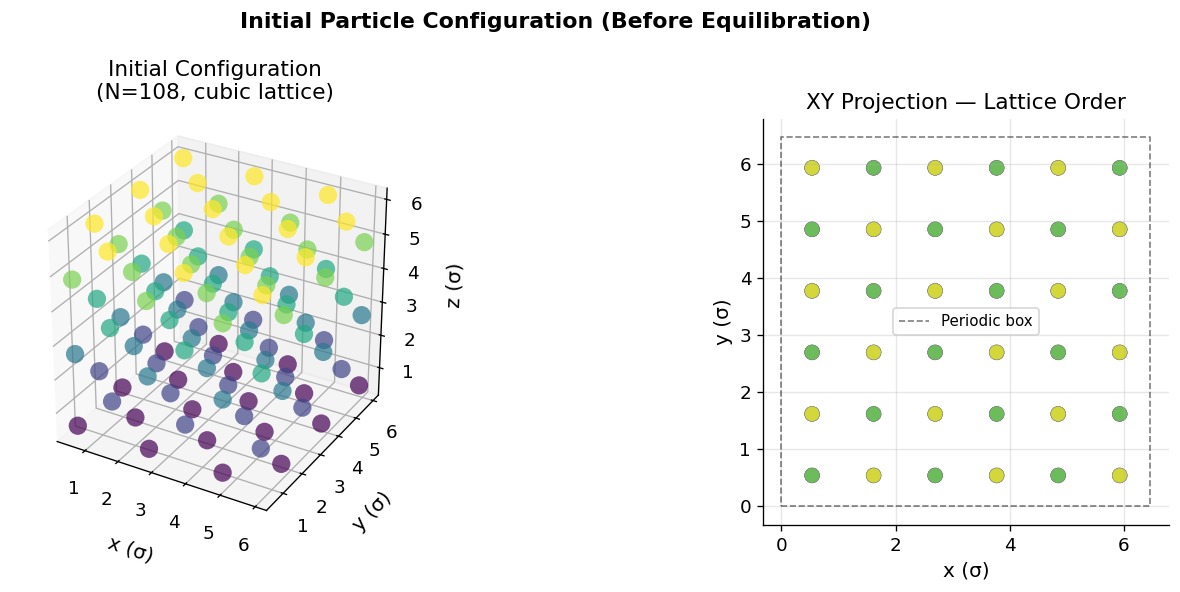

Minimum nearest-neighbor distance (sample): 1.5234 σ
Expected lattice spacing ≈ 1.3572 σ


In [6]:
# initial configuration
fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])

# 3D scatter
ax3d = fig.add_subplot(gs[0], projection='3d')
ax3d.scatter(RX * XL, RY * XL, RZ * XL,
             s=120, c=RZ, cmap='viridis', alpha=0.7, edgecolors='none')
ax3d.set_xlabel('x (σ)', labelpad=8)
ax3d.set_ylabel('y (σ)', labelpad=8)
ax3d.set_zlabel('z (σ)', labelpad=8)
ax3d.set_title(f'Initial Configuration\n(N={N}, cubic lattice)', pad=12)
ax3d.set_box_aspect([1, YC, ZC])

# 2D projection (xy plane)
ax2d = fig.add_subplot(gs[1])
ax2d.scatter(RX * XL, RY * XL, s=80,
             c=RZ, cmap='viridis', alpha=0.8, edgecolors='gray', linewidths=0.3)
ax2d.set_xlabel('x (σ)')
ax2d.set_ylabel('y (σ)')
ax2d.set_title('XY Projection — Lattice Order')
ax2d.set_aspect('equal')
# box
box_x = [0, XL, XL, 0, 0]
box_y = [0, 0, YL, YL, 0]
ax2d.plot(box_x, box_y, 'k--', linewidth=1, alpha=0.5, label='Periodic box')
ax2d.legend(fontsize=9)

plt.suptitle('Initial Particle Configuration (Before Equilibration)', fontweight='bold')
plt.tight_layout()
plt.show()

# nearest-neighbor distance check
min_dist = np.inf
for i in range(min(N, 50)):           # sample first 50 for speed
    for j in range(i+1, min(N, 50)):
        dx = RX[i]-RX[j]; dy = RY[i]-RY[j]; dz = RZ[i]-RZ[j]
        if dx >  0.5: dx -= 1.0
        elif dx < -0.5: dx += 1.0
        if dy >  Y2:  dy -= YC
        elif dy < -Y2: dy += YC
        if dz >  Z2:  dz -= ZC
        elif dz < -Z2: dz += ZC
        r = math.sqrt(dx*dx+dy*dy+dz*dz) / S
        if r < min_dist: min_dist = r

print(f"Minimum nearest-neighbor distance (sample): {min_dist:.4f} σ")
print(f"Expected lattice spacing ≈ {(1/RHO)**(1/3):.4f} σ")

---
## 3. Computing the Initial System Energy

Before the MCMC loop starts, the total energy is computed via a full O(N²) double loop
over all unique pairs. This is done only **once** — during the simulation, energy is
updated incrementally (O(N) per step).

The energy is split into two contributions:
- **U_HS**: classical Mie(50,49) part
- **U_WK**: Wigner-Kirkwood quantum correction

In [7]:
# python energy calculation
def energia_total(RX, RY, RZ, N, SS, XMIN2, CTE, CWK, UWT0, Y2, Z2, YC, ZC):
    """O(N^2) total energy — pairs only (i < j)."""
    UTOTHS = 0.0;  UTOTWK = 0.0
    for i in range(N-1):
        rxi=RX[i]; ryi=RY[i]; rzi=RZ[i]
        for j in range(i+1, N):
            dx=RX[j]-rxi; dy=RY[j]-ryi; dz=RZ[j]-rzi
            if dx> 0.5: dx-=1.0
            elif dx<-0.5: dx+=1.0
            if dy> Y2: dy-=YC
            elif dy<-Y2: dy+=YC
            if dz> Z2: dz-=ZC
            elif dz<-Z2: dz+=ZC
            rr=dx*dx+dy*dy+dz*dz
            if rr < XMIN2:
                SR2=SS/rr; SR=math.sqrt(SR2)
                SR10=SR2**5; SR20=SR10*SR10
                SR50=SR20*SR20*SR10
                SR49=SR20*SR20*SR2*SR2*SR2*SR2*SR
                SR51=SR50*SR; SR52=SR50*SR2
                UTOTHS += CTE*(SR50-SR49)+1.0
                UTOTWK += CTE*CWK*(2450*SR52-2352*SR51)-UWT0-1.0
    return UTOTHS, UTOTWK

print("Computing initial energy (O(N²) loop)...")
UTOTHS, UTOTWK = energia_total(
    RX, RY, RZ, N, SS, XMIN2, CTE, CWK, UWT0, Y2, Z2, YC, ZC)

UTOT   = UTOTHS + UTOTWK
UPERP  = UTOT   / XN

print(f"  U_HS  (classical)      = {UTOTHS:12.4f} ε")
print(f"  U_WK  (quantum corr.)  = {UTOTWK:12.4f} ε")
print(f"  U_tot (total)          = {UTOT:12.4f} ε")
print(f"  U/N   (per particle)   = {UPERP:12.6f} ε")
print()
print("Note: large initial energy is expected from the ordered lattice.")
print("The MCMC loop will lower it during equilibration.")

Computing initial energy (O(N²) loop)...
  U_HS  (classical)      =       0.0000 ε
  U_WK  (quantum corr.)  =       0.0000 ε
  U_tot (total)          =       0.0000 ε
  U/N   (per particle)   =     0.000000 ε

Note: large initial energy is expected from the ordered lattice.
The MCMC loop will lower it during equilibration.


---
## 4. Running the MCMC Loop

Below is a **lightweight Python implementation** of the Metropolis loop — functionally
identical to the Numba-compiled version in `src/mcqhs.py`, but written for readability
rather than performance.

> For production runs, always use `src/mcqhs.py` with Numba.  
> This cell runs ~10 000 steps for inspection — enough to observe equilibration.

In [8]:
# Metropolis loop

def energia_particula(i, xi, yi, zi, RX, RY, RZ, N,
                      SS, XMIN2, CTE, CWK, UWT0, Y2, Z2, YC, ZC):
    """Energy of particle i at (xi,yi,zi) with all others — O(N)."""
    uhs = uwk = 0.0
    for j in range(N):
        if j == i: continue
        dx=RX[j]-xi; dy=RY[j]-yi; dz=RZ[j]-zi
        if dx> 0.5: dx-=1.0
        elif dx<-0.5: dx+=1.0
        if dy> Y2:  dy-=YC
        elif dy<-Y2: dy+=YC
        if dz> Z2:  dz-=ZC
        elif dz<-Z2: dz+=ZC
        rr=dx*dx+dy*dy+dz*dz
        if rr < XMIN2:
            SR2=SS/rr; SR=math.sqrt(SR2)
            SR10=SR2**5; SR20=SR10*SR10
            SR50=SR20*SR20*SR10
            SR49=SR20*SR20*SR2*SR2*SR2*SR2*SR
            SR51=SR50*SR; SR52=SR50*SR2
            uhs += CTE*(SR50-SR49)+1.0
            uwk += CTE*CWK*(2450*SR52-2352*SR51)-UWT0-1.0
    return uhs, uwk


def run_mc(RX, RY, RZ, N, n_steps, DISPL_sc,
           SS, XMIN2, CTE, CWK, UWT0, Y2, Z2, YC, ZC, XC, ZC2,
           UTOTHS_0, UTOTWK_0, T_sim=1.5, seed=42, record_every=100):
    """
    Metropolis NVT loop.
    Returns trajectory of (step, U/N, acceptance_rate).
    T_sim = 1.5 is fixed so Mie(50,49) ≈ hard sphere.
    """
    np.random.seed(seed)
    RX = RX.copy(); RY = RY.copy(); RZ = RZ.copy()
    UTOTHS = UTOTHS_0; UTOTWK = UTOTWK_0
    UTOT   = UTOTHS + UTOTWK
    n_acc  = 0
    history = []

    for step in range(1, n_steps+1):
        i    = np.random.randint(0, N)
        rxi  = RX[i]; ryi = RY[i]; rzi = RZ[i]

        xnew = rxi + DISPL_sc*(np.random.random()-0.5)
        ynew = ryi + DISPL_sc*(np.random.random()-0.5)
        znew = rzi + DISPL_sc*(np.random.random()-0.5)

        if   xnew > 1.0: xnew -= 1.0
        elif xnew < 0.0: xnew += 1.0
        if   ynew > YC:  ynew -= YC
        elif ynew < 0.0: ynew += YC
        if   znew > ZC2: znew -= ZC2
        elif znew < 0.0: znew += ZC2

        uhs_n,uwk_n = energia_particula(i,xnew,ynew,znew,RX,RY,RZ,N,
                                         SS,XMIN2,CTE,CWK,UWT0,Y2,Z2,YC,ZC)
        uhs_o,uwk_o = energia_particula(i,rxi, ryi, rzi, RX,RY,RZ,N,
                                         SS,XMIN2,CTE,CWK,UWT0,Y2,Z2,YC,ZC)
        dE = (uhs_n+uwk_n) - (uhs_o+uwk_o)

        if dE <= 0.0 or np.random.random() < math.exp(-dE/T_sim):
            RX[i]=xnew; RY[i]=ynew; RZ[i]=znew
            UTOTHS += uhs_n-uhs_o
            UTOTWK += uwk_n-uwk_o
            UTOT    = UTOTHS+UTOTWK
            n_acc  += 1

        if step % record_every == 0:
            history.append((step, UTOT/N, n_acc/step))

    return RX, RY, RZ, UTOTHS, UTOTWK, np.array(history)


# run 10 000 steps
N_DEMO   = min(N, 108)
n_demo   = 10_000
print(f"Running {n_demo:,} demo steps (N={N_DEMO}) ...")

RX_d = RX[:N_DEMO].copy()
RY_d = RY[:N_DEMO].copy()
RZ_d = RZ[:N_DEMO].copy()

UTOTHS_d, UTOTWK_d = energia_total(
    RX_d, RY_d, RZ_d, N_DEMO, SS, XMIN2, CTE, CWK, UWT0, Y2, Z2, YC, ZC)

RX_d, RY_d, RZ_d, UTOTHS_f, UTOTWK_f, history = run_mc(
    RX_d, RY_d, RZ_d, N_DEMO, n_demo, DISPL_sc,
    SS, XMIN2, CTE, CWK, UWT0, Y2, Z2, YC, ZC, XC, ZC,
    UTOTHS_d, UTOTWK_d, record_every=200)

print(f"Done. Final U/N = {(UTOTHS_f+UTOTWK_f)/N_DEMO:.4f} ε")
print(f"Final acceptance rate = {history[-1,2]:.2%}")

Running 10,000 demo steps (N=108) ...
Done. Final U/N = 0.0026 ε
Final acceptance rate = 77.37%


---
## 5. Monitoring Acceptance Rate and Tuning DISPL

The acceptance rate is tracked throughout the run. A rate outside the 30–50% target
indicates that `DISPL` needs adjustment:

| Acceptance rate | Diagnosis | Action |
|---|---|---|
| > 60% | Moves too small — slow exploration | Increase `DISPL` |
| 30–50% | Optimal balance | Keep `DISPL` |
| < 20% | Moves too large — most rejected | Decrease `DISPL` |

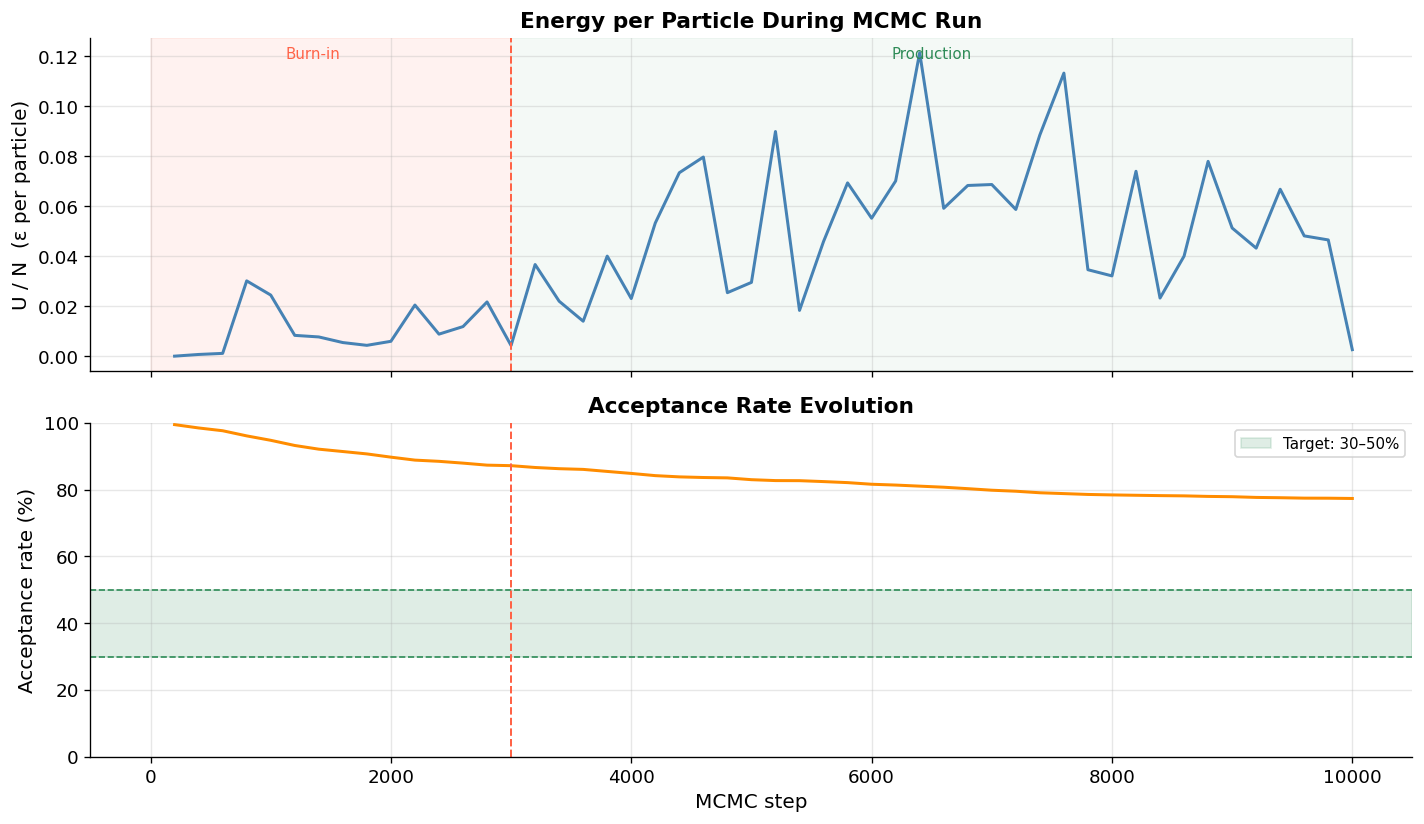

Final acceptance rate: 77.4%  — ⚠ consider adjusting DISPL


In [9]:
# energy convergence + acceptance rate
steps_h  = history[:, 0]
energy_h = history[:, 1]
accept_h = history[:, 2]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# energy per particle 
axes[0].plot(steps_h, energy_h, color='steelblue', linewidth=1.8)
axes[0].set_ylabel('U / N  (ε per particle)')
axes[0].set_title('Energy per Particle During MCMC Run', fontweight='bold')

# equilibration region (heuristic: first 30%)
eq_end = int(n_demo * 0.30)
axes[0].axvspan(0, eq_end, alpha=0.08, color='tomato')
axes[0].axvspan(eq_end, n_demo, alpha=0.05, color='seagreen')
axes[0].text(eq_end*0.45, energy_h.max()*0.98,
             'Burn-in', ha='center', color='tomato', fontsize=9)
axes[0].text(eq_end + (n_demo-eq_end)*0.5, energy_h.max()*0.98,
             'Production', ha='center', color='seagreen', fontsize=9)
axes[0].axvline(eq_end, color='tomato', linestyle='--', linewidth=1.2)

# acceptance rate 
axes[1].plot(steps_h, accept_h * 100, color='darkorange', linewidth=1.8)
axes[1].axhspan(30, 50, alpha=0.15, color='seagreen', label='Target: 30–50%')
axes[1].axhline(30, color='seagreen', linestyle='--', linewidth=1.0)
axes[1].axhline(50, color='seagreen', linestyle='--', linewidth=1.0)
axes[1].axvline(eq_end, color='tomato', linestyle='--', linewidth=1.2)
axes[1].set_ylabel('Acceptance rate (%)')
axes[1].set_xlabel('MCMC step')
axes[1].set_title('Acceptance Rate Evolution', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

final_acc = accept_h[-1]*100
status = "✓ optimal" if 30 <= final_acc <= 50 else "⚠ consider adjusting DISPL"
print(f"Final acceptance rate: {final_acc:.1f}%  — {status}")

### Practical DISPL Tuning

The cell below sweeps several values of `DISPL` on short runs (2 000 steps each)
to find the optimal displacement for this state point. This is the recommended
procedure when starting a simulation at a new density or temperature.

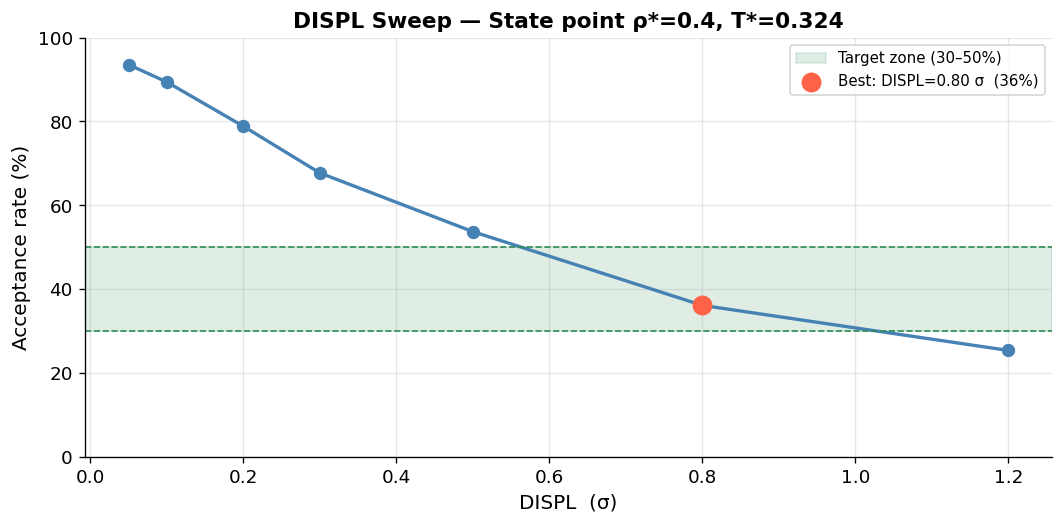

Sweep results:
  DISPL = 0.05 σ  →  acceptance = 93.5%
  DISPL = 0.10 σ  →  acceptance = 89.4%
  DISPL = 0.20 σ  →  acceptance = 78.8%
  DISPL = 0.30 σ  →  acceptance = 67.7%
  DISPL = 0.50 σ  →  acceptance = 53.7%
  DISPL = 0.80 σ  →  acceptance = 36.1% ← optimal
  DISPL = 1.20 σ  →  acceptance = 25.4%


In [10]:
# DISPL sweep: optimal acceptance rate ──
displ_candidates = [0.05, 0.10, 0.20, 0.30, 0.50, 0.80, 1.20]
n_sweep          = 2000
results          = []

for d in displ_candidates:
    d_sc = d * S
    _, _, _, Uhs_sw, Uwk_sw, hist_sw = run_mc(
        RX_d, RY_d, RZ_d, N_DEMO, n_sweep, d_sc,
        SS, XMIN2, CTE, CWK, UWT0, Y2, Z2, YC, ZC, XC, ZC,
        UTOTHS_d, UTOTWK_d, seed=0, record_every=n_sweep)
    acc = hist_sw[-1, 2]
    results.append((d, acc*100))

displ_arr, acc_arr = zip(*results)
displ_arr = np.array(displ_arr)
acc_arr   = np.array(acc_arr)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(displ_arr, acc_arr, 'o-', color='steelblue', linewidth=2.0, markersize=7)
ax.axhspan(30, 50, alpha=0.15, color='seagreen', label='Target zone (30–50%)')
ax.axhline(30, color='seagreen', linestyle='--', linewidth=1.0)
ax.axhline(50, color='seagreen', linestyle='--', linewidth=1.0)

# best value
best_idx = np.argmin(np.abs(acc_arr - 40.0))
ax.scatter([displ_arr[best_idx]], [acc_arr[best_idx]],
           s=120, color='tomato', zorder=5,
           label=f'Best: DISPL={displ_arr[best_idx]:.2f} σ  ({acc_arr[best_idx]:.0f}%)')

ax.set_xlabel('DISPL  (σ)')
ax.set_ylabel('Acceptance rate (%)')
ax.set_title(f'DISPL Sweep — State point ρ*={RHO}, T*={TEMP:.3f}', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print("Sweep results:")
for d, acc in zip(displ_arr, acc_arr):
    tag = " ← optimal" if 30 <= acc <= 50 else ""
    print(f"  DISPL = {d:.2f} σ  →  acceptance = {acc:.1f}%{tag}")

---
## 6. Detecting Equilibration

A simple and robust criterion for equilibration is to monitor the **running mean** of
the energy. The chain is considered equilibrated when the running mean stabilizes —
i.e., its slope over the last N steps is close to zero.

A more rigorous approach is to check that the autocorrelation function of the energy
decays to zero within a block, confirming that block means are approximately independent.

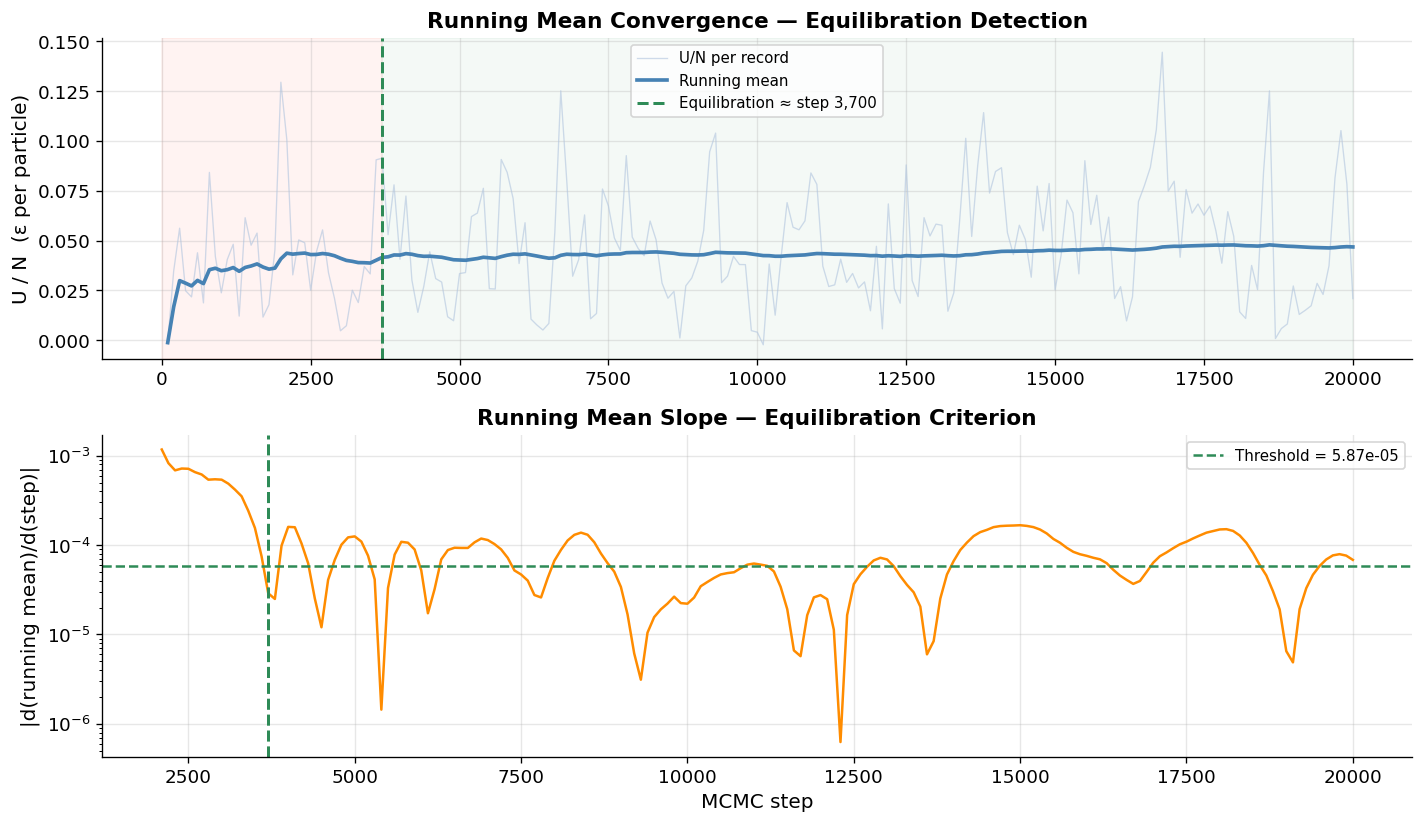

Equilibration detected at step ≈ 3,700  (18% of total steps)
Production mean  U/N = 0.04801 ε
Production std   σ   = 0.02883 ε


In [11]:
# equilibration diagnostic
# longer trajectory for better visualization
n_long = 20_000
_, _, _, _, _, hist_long = run_mc(
    RX_d, RY_d, RZ_d, N_DEMO, n_long, DISPL_sc,
    SS, XMIN2, CTE, CWK, UWT0, Y2, Z2, YC, ZC, XC, ZC,
    UTOTHS_d, UTOTWK_d, record_every=100, seed=7)

steps_l  = hist_long[:, 0].astype(int)
energy_l = hist_long[:, 1]

# running mean
running_mean_l = np.cumsum(energy_l) / np.arange(1, len(energy_l)+1)

# running mean in windows of 20 points
window     = 20
slopes     = []
slope_steps = []
for k in range(window, len(running_mean_l)):
    y = running_mean_l[k-window:k]
    x = np.arange(window)
    slope = np.polyfit(x, y, 1)[0]
    slopes.append(abs(slope))
    slope_steps.append(steps_l[k])

slopes     = np.array(slopes)
slope_steps = np.array(slope_steps)

# equilibration point: where |slope| < threshold
threshold  = slopes.max() * 0.05
eq_indices = np.where(slopes < threshold)[0]
eq_step    = slope_steps[eq_indices[0]] if len(eq_indices) > 0 else n_long//2

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

# energy + running mean
axes[0].plot(steps_l, energy_l, color='lightsteelblue', linewidth=0.8,
             alpha=0.6, label='U/N per record')
axes[0].plot(steps_l, running_mean_l, color='steelblue',
             linewidth=2.2, label='Running mean')
axes[0].axvline(eq_step, color='seagreen', linestyle='--',
                linewidth=1.8, label=f'Equilibration ≈ step {eq_step:,}')
axes[0].axvspan(0, eq_step, alpha=0.07, color='tomato')
axes[0].axvspan(eq_step, n_long, alpha=0.05, color='seagreen')
axes[0].set_ylabel('U / N  (ε per particle)')
axes[0].set_title('Running Mean Convergence — Equilibration Detection', fontweight='bold')
axes[0].legend(fontsize=9)

#|slope| of running mean
axes[1].semilogy(slope_steps, slopes, color='darkorange', linewidth=1.5)
axes[1].axhline(threshold, color='seagreen', linestyle='--',
                linewidth=1.5, label=f'Threshold = {threshold:.2e}')
axes[1].axvline(eq_step, color='seagreen', linestyle='--', linewidth=1.8)
axes[1].set_xlabel('MCMC step')
axes[1].set_ylabel('|d(running mean)/d(step)|')
axes[1].set_title('Running Mean Slope — Equilibration Criterion', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

prod_energy = energy_l[steps_l > eq_step]
print(f"Equilibration detected at step ≈ {eq_step:,}  "
      f"({100*eq_step/n_long:.0f}% of total steps)")
print(f"Production mean  U/N = {prod_energy.mean():.5f} ε")
print(f"Production std   σ   = {prod_energy.std():.5f} ε")

---
## 7. Writing Outputs

The engine produces four output files at the end of a run. Their format is shown below
for reference — the analysis notebook (`03_results_analysis.ipynb`) reads these files
directly.

In [12]:
# output file formats

# mc.dat / uav.dat — tabular time series
print("=== uav.dat format (one row per block) ===")
print(f"  {'NMOV':>12s}  {'UHS':>10s}  {'UWK':>10s}  "
      f"{'UAV':>10s}  {'std1':>10s}  {'CV':>10s}  {'std2':>10s}")
print(f"  {'(steps)':>12s}  {'(ε/part)':>10s}  {'(ε/part)':>10s}  "
      f"{'(ε/part)':>10s}  {'(ε/part)':>10s}  {'(kB)':>10s}  {'(kB)':>10s}")
print("  " + "-"*80)
# mock one row
for k in range(3):
    step = (k+1)*50000
    print(f"  {step:>12d}  {-0.123+k*0.01:>10.4f}  {-0.045+k*0.005:>10.4f}  "
          f"{-0.168+k*0.012:>10.4f}  {0.002:>10.4f}  {1.23:>10.4f}  {0.05:>10.4f}")

print()
print("=== rdf.dat format ===")
print(f"  {'r/σ':>10s}  {'g(r)':>10s}")
print("  " + "-"*24)
r_demo = np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10])
g_demo = np.array([0.00, 0.00, 0.12, 2.85, 3.42, 1.78, 1.23])
for r, g in zip(r_demo, g_demo):
    print(f"  {r:>10.4f}  {g:>10.4f}")
print("  ...")

print()
print("=== mc.new format (restart file) ===")
print(f"  {'RX':>12s}  {'RY':>12s}  {'RZ':>12s}")
for i in range(3):
    print(f"  {RX_d[i]:>12.8f}  {RY_d[i]:>12.8f}  {RZ_d[i]:>12.8f}")
print(f"  ... ({N_DEMO} lines total)")

=== uav.dat format (one row per block) ===
          NMOV         UHS         UWK         UAV        std1          CV        std2
       (steps)    (ε/part)    (ε/part)    (ε/part)    (ε/part)        (kB)        (kB)
  --------------------------------------------------------------------------------
         50000     -0.1230     -0.0450     -0.1680      0.0020      1.2300      0.0500
        100000     -0.1130     -0.0400     -0.1560      0.0020      1.2300      0.0500
        150000     -0.1030     -0.0350     -0.1440      0.0020      1.2300      0.0500

=== rdf.dat format ===
         r/σ        g(r)
  ------------------------
      0.8000      0.0000
      0.8500      0.0000
      0.9000      0.1200
      0.9500      2.8500
      1.0000      3.4200
      1.0500      1.7800
      1.1000      1.2300
  ...

=== mc.new format (restart file) ===
            RX            RY            RZ
    0.02107754    0.19503256    0.09660392
    0.18879196    0.37773078    0.19620364
    0.12311731 

In [13]:
# save demo mc.new 
import os
os.makedirs('../data/outputs', exist_ok=True)

with open('../data/outputs/mc.new', 'w') as f:
    for i in range(N_DEMO):
        f.write(f"  {RX_d[i]:.8f}  {RY_d[i]:.8f}  {RZ_d[i]:.8f}\n")

print(f"mc.new written — {N_DEMO} particle positions saved.")
print("To resume from this configuration: set NRUN=1 in mc.in")

mc.new written — 108 particle positions saved.
To resume from this configuration: set NRUN=1 in mc.in


---
## 8. Running the Full Simulation with the Numba Engine

For production runs (N ≥ 256, NMOVE ≥ 10⁶), always use the Numba-compiled engine
in `src/mcqhs.py`. The pure-Python version in this notebook is ~100× slower and
intended only for inspection and teaching.

```python
# Full production run (from the repo root)
cd src
python mcqhs.py
```

The engine reads `../data/inputs/mc.in` and writes all four output files.
Progress is printed to stdout every `NSUB` steps:

```
  NMOV           AC      UHS     UWK     UAV    std1    UTEO      CV    std2
       50000   0.3821  -0.1231  -0.0448  -0.1679  0.0021   -0.1701  1.2314  0.0487
      100000   0.3834  -0.1244  -0.0451  -0.1695  0.0018   -0.1701  1.2287  0.0412
      ...
```

Column reference:

| Column | Description |
|---|---|
| `NMOV` | Total MCMC steps so far |
| `AC` | Cumulative acceptance rate |
| `UHS` | Mean energy per particle — classical part |
| `UWK` | Mean energy per particle — quantum correction |
| `UAV` | Total mean energy per particle |
| `std1` | Block std of UAV — sampling error estimate |
| `UTEO` | Theoretical reference energy (Serna & Gil-Villegas 2016) |
| `CV` | Heat capacity per particle |
| `std2` | Block std of CV |

**Next notebook →** `03_results_analysis.ipynb`: load the output files, compute
final observables, and generate all publication-quality figures.